# imports

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate, learning_curve, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, log_loss, brier_score_loss, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# seed setting

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Default setting

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pd.set_option("display.max_columns", None)

PALETTE = {"Not creditworthy": "#C44E52", "Creditworthy": "#55A868"}
LABEL_MAP = {0: "Not creditworthy", 1: "Creditworthy"}


# import dataset

In [4]:
credit = pd.read_csv("data.csv", header=0)
credit.head()

,Age,Gender,Education,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Payment_History,Employment_Status,Residence_Type,Marital_Status,Creditworthiness
0,56,Female,Master,149406,34089,581,49200,60,4,Bad,Unemployed,Rented,Single,1
1,69,Female,High School,78896,8626,648,20147,24,7,Good,Employed,Mortgaged,Married,1
2,46,Female,Master,119339,46281,329,41307,12,8,Bad,Unemployed,Owned,Single,1
3,32,Male,High School,131067,29403,816,19019,60,8,Bad,Employed,Owned,Single,1
4,60,Male,PhD,38001,30032,673,16317,36,4,Average,Employed,Rented,Married,0


# dividing categorical data from numerical

In [ ]:
numerical_features = credit.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = credit.select_dtypes(include=["object", "category"]).columns.tolist()

%matplotlib inline

/tmp/ipykernel_3413/3271636891.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = credit.select_dtypes(include=["object", "category"]).columns.tolist()


# EDA

/tmp/ipykernel_3413/2978752782.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_eda, x=feat, hue="Creditworthiness_label", fill=True,


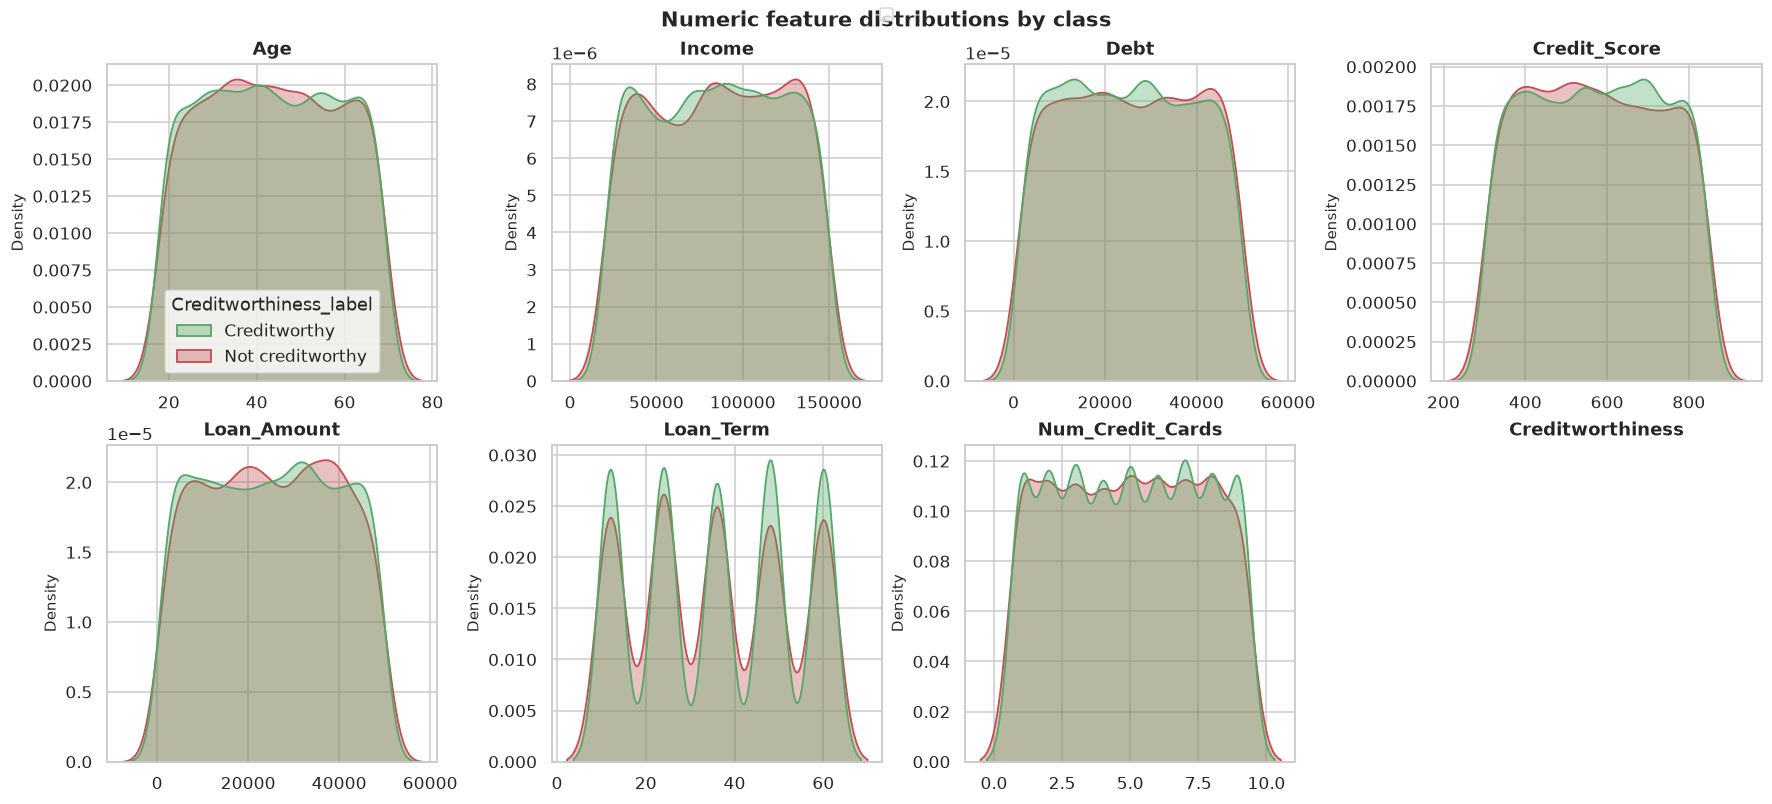

In [6]:
df_eda = credit.copy()
df_eda["Creditworthiness_label"] = df_eda["Creditworthiness"].map(LABEL_MAP)

fig, axes = plt.subplots(2, 4, figsize=(16, 7.2), constrained_layout=True)
for i, (ax, feat) in enumerate(zip(axes.flat, numerical_features)):
    sns.kdeplot(data=df_eda, x=feat, hue="Creditworthiness_label", fill=True,
                common_norm=False, palette=PALETTE, alpha=0.35, linewidth=1.2, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    if i > 0 and ax.get_legend() is not None:
        ax.get_legend().remove()
axes.flat[-1].axis("off")
h, l = axes.flat[0].get_legend_handles_labels()
fig.legend(h, l, loc="outside upper center", ncol=2, frameon=True)
fig.suptitle("Numeric feature distributions by class", fontsize=14, fontweight="bold")
plt.show()

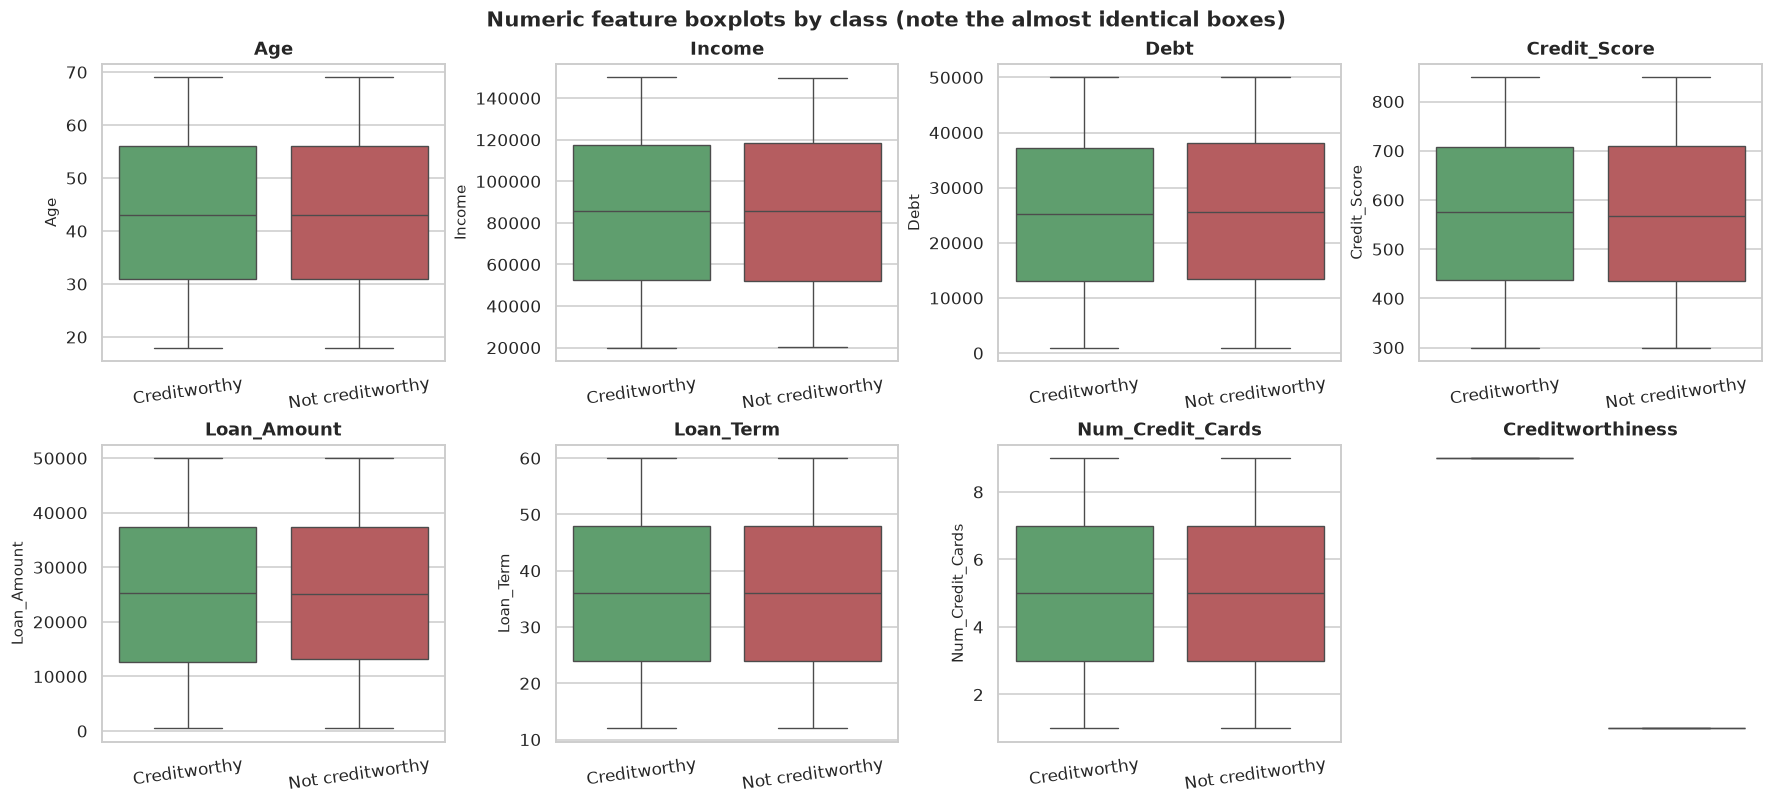

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7.2), constrained_layout=True)
for i, (ax, feat) in enumerate(zip(axes.flat, numerical_features)):
    sns.boxplot(data=df_eda, x="Creditworthiness_label", y=feat,
                hue="Creditworthiness_label", palette=PALETTE, legend=False,
                fliersize=1.2, linewidth=0.9, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=8)
axes.flat[-1].axis("off")
fig.suptitle("Numeric feature boxplots by class (note the almost identical boxes)",
             fontsize=14, fontweight="bold")
plt.show()

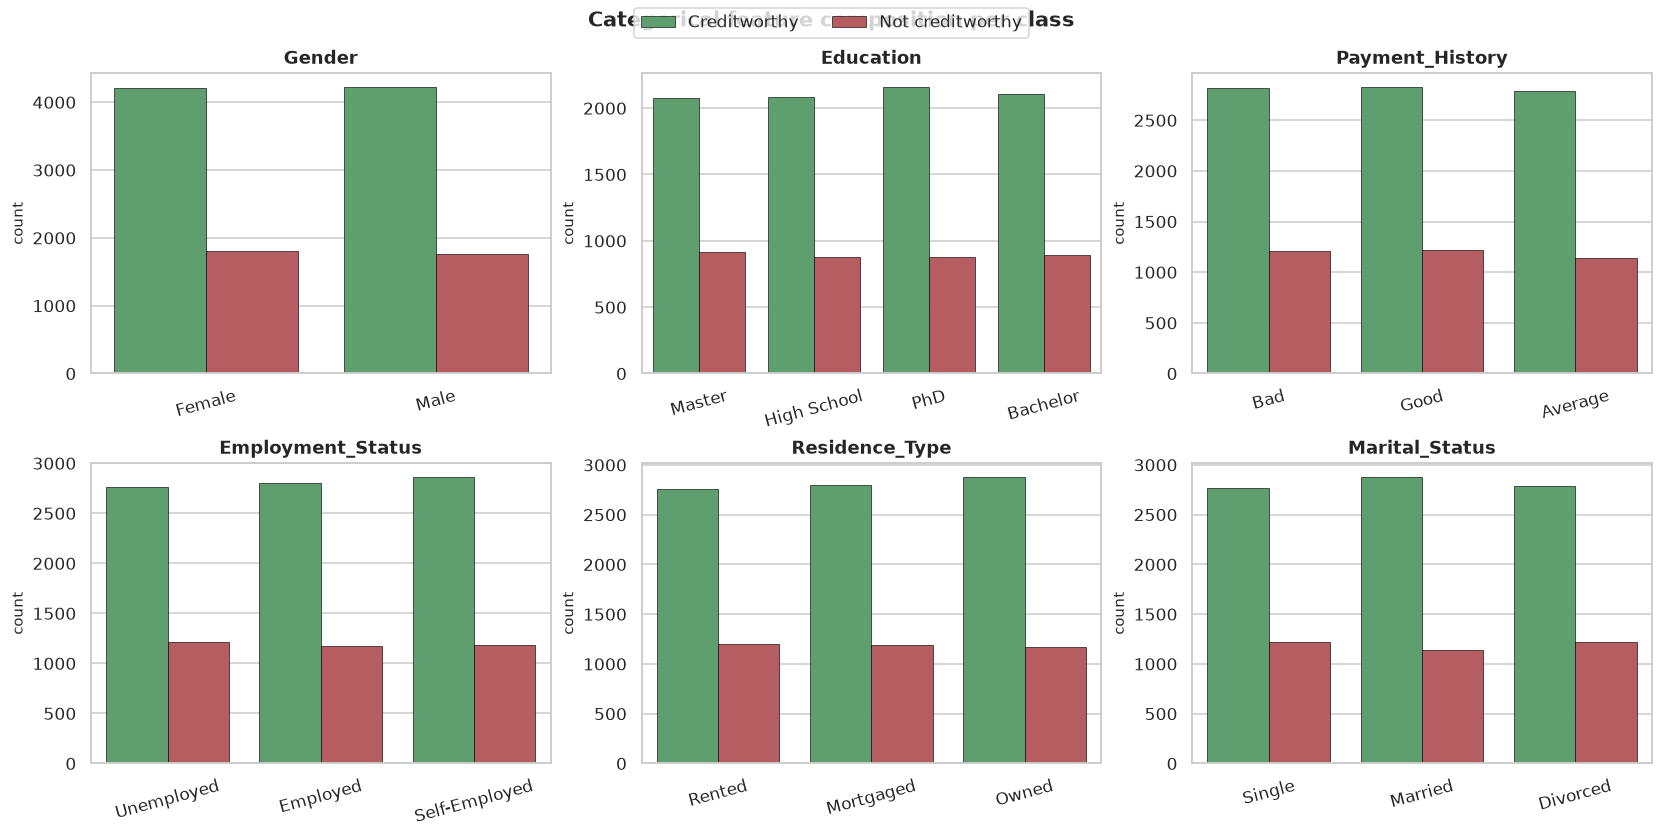

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), constrained_layout=True)
for ax, feat in zip(axes.flat, categorical_features):
    sns.countplot(data=df_eda, x=feat, hue="Creditworthiness_label",
                  palette=PALETTE, edgecolor="black", linewidth=0.4, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
h, l = axes.flat[0].get_legend_handles_labels()
fig.legend(h, l, loc="outside upper center", ncol=2, frameon=True)
fig.suptitle("Categorical feature composition per class", fontsize=14, fontweight="bold")
plt.show()

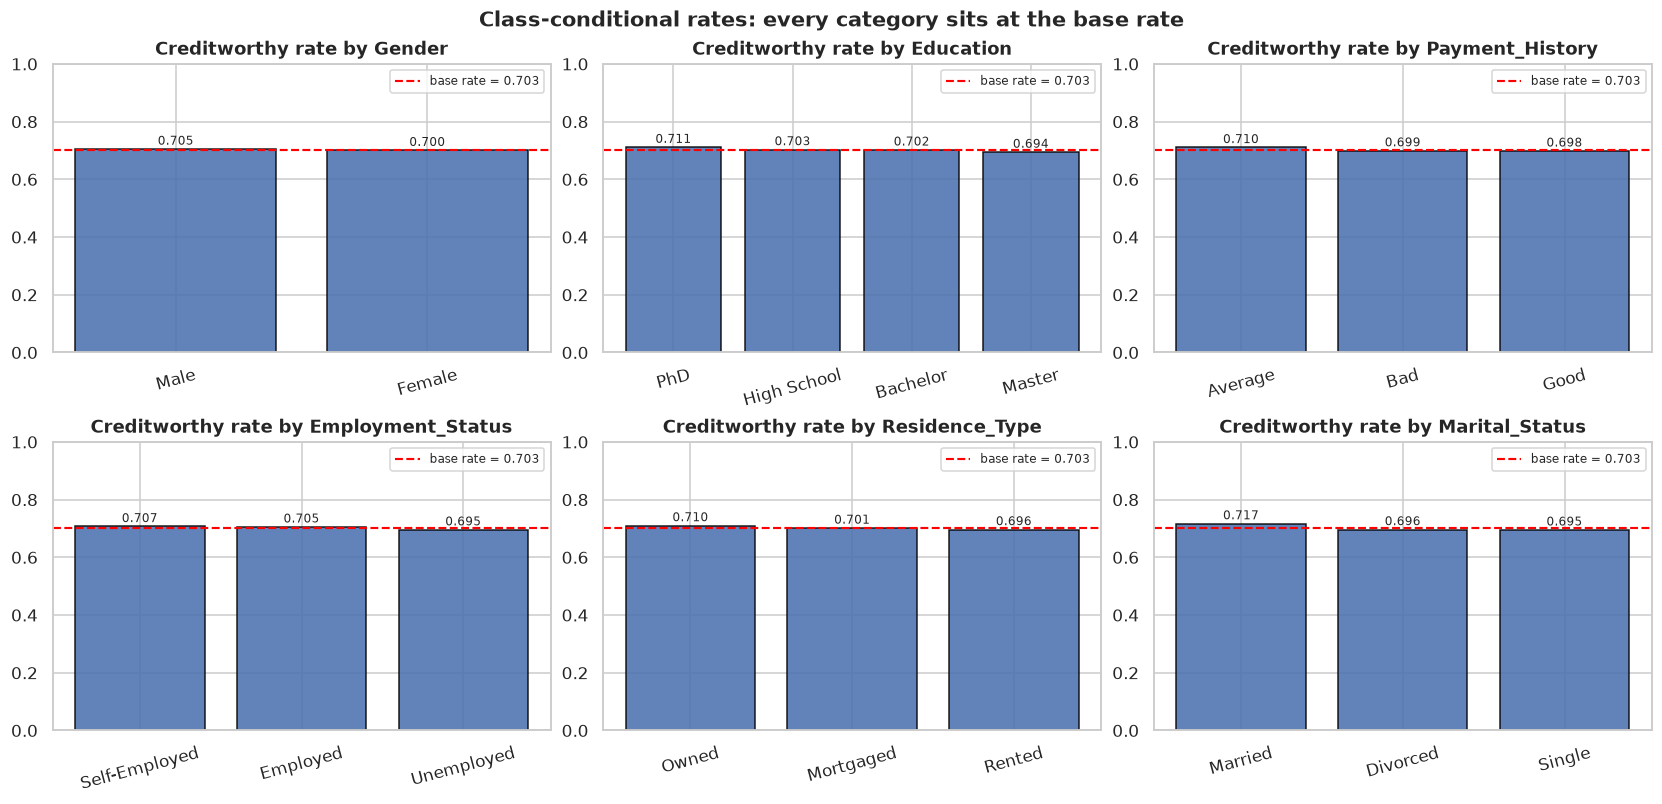

In [9]:
base_rate = credit["Creditworthiness"].mean()
fig, axes = plt.subplots(2, 3, figsize=(15, 7.2), constrained_layout=True)
for ax, feat in zip(axes.flat, categorical_features):
    rate = credit.groupby(feat)["Creditworthiness"].mean().sort_values(ascending=False)
    ax.bar(rate.index, rate.values, color="#4C72B0", alpha=0.88, edgecolor="black")
    ax.axhline(base_rate, color="red", ls="--", lw=1.4,
               label=f"base rate = {base_rate:.3f}")
    for x, v in enumerate(rate.values):
        ax.text(x, v + 0.015, f"{v:.3f}", ha="center", fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"Creditworthy rate by {feat}")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Class-conditional rates: every category sits at the base rate",
             fontsize=14, fontweight="bold")
plt.show()

In [13]:
credit.head()

,Age,Gender,Education,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Payment_History,Employment_Status,Residence_Type,Marital_Status,Creditworthiness
0,56,Female,Master,149406,34089,581,49200,60,4,Bad,Unemployed,Rented,Single,1
1,69,Female,High School,78896,8626,648,20147,24,7,Good,Employed,Mortgaged,Married,1
2,46,Female,Master,119339,46281,329,41307,12,8,Bad,Unemployed,Owned,Single,1
3,32,Male,High School,131067,29403,816,19019,60,8,Bad,Employed,Owned,Single,1
4,60,Male,PhD,38001,30032,673,16317,36,4,Average,Employed,Rented,Married,0


# Define correlation matrix and input + output of models

In [34]:
corr = credit[numerical_features].corr()
target_corr = corr["Creditworthiness"].drop("Creditworthiness").sort_values(ascending = False)
rate = credit.groupby("Creditworthiness")[["Creditworthiness"]].mean()
corr

X = credit.drop(columns="Creditworthiness").copy()
y = credit["Creditworthiness"].copy()

numerical_features   = [c for c in numerical_features   if c != "Creditworthiness"]
categorical_features = [c for c in categorical_features if c != "Creditworthiness"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,)

# define preprocessing + pipeline steps

In [35]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numerical_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_features),
        ],
        sparse_threshold=0,
    )

def make_pipeline(model):
    "Preprocessor -> model; fitted on training folds only at CV time (no leakage)."
    return Pipeline([("preprocessor", make_preprocessor()), ("model", model)])

_peek = make_pipeline(DummyClassifier()).fit(X_train, y_train)
feature_names = [n.split("__", 1)[1]
                 for n in _peek.named_steps["preprocessor"].get_feature_names_out()]

In [36]:
dummy_pipe = make_pipeline(DummyClassifier(strategy="most_frequent"))
dummy_res = cross_validate(dummy_pipe, X_train, y_train, cv=CV,
                           scoring=["accuracy", "roc_auc"], n_jobs=-1)

# models stack + metrics

In [37]:
baseline_models = {
    "Dummy (majority)": DummyClassifier(strategy="most_frequent"),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
}

SCORING = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
           "roc_auc": "roc_auc", "f1": "f1"}

rows = []
for name, model in baseline_models.items():
    res = cross_validate(make_pipeline(model), X_train, y_train,
                         cv=CV, scoring=SCORING, n_jobs=-1)
    rows.append({
        "Model": name,
        "Accuracy": res["test_accuracy"].mean(),
        "Balanced acc": res["test_balanced_accuracy"].mean(),
        "ROC-AUC": res["test_roc_auc"].mean(),
        "F1 (positive)": res["test_f1"].mean(),
        "Fit time (s)": res["fit_time"].mean(),
    })
    print(f"validated: {name}")

baseline_df = pd.DataFrame(rows)
baseline_df.round(4)

validated: Dummy (majority)
validated: Decision Tree
validated: Random Forest
validated: Gradient Boosting
validated: Logistic Regression
validated: KNN


,Model,Accuracy,Balanced acc,ROC-AUC,F1 (positive),Fit time (s)
0,Dummy (majority),0.7026,0.5000,0.5000,0.8253,0.1327
1,Decision Tree,0.5737,0.5022,0.5022,0.6911,0.2996
2,Random Forest,0.7017,0.5013,0.5067,0.8243,3.3495
3,Gradient Boosting,0.6984,0.4987,0.5054,0.8221,2.1716
4,Logistic Regression,0.7026,0.5000,0.4900,0.8253,0.0471
5,KNN,0.6374,0.5007,0.5016,0.7646,0.0474


# cross validation visualization 

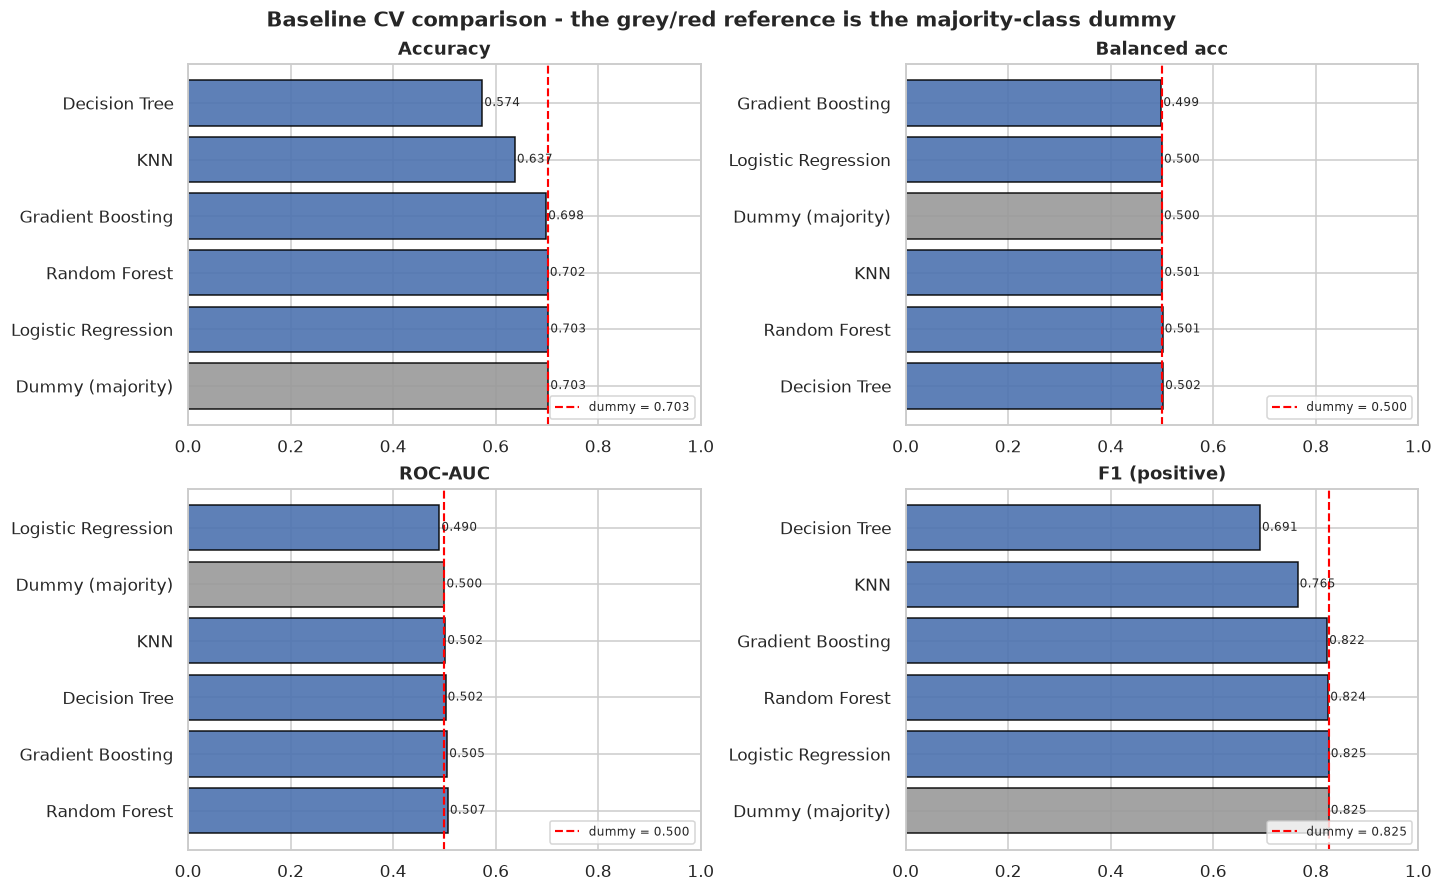

In [38]:
metrics_to_plot = ["Accuracy", "Balanced acc", "ROC-AUC", "F1 (positive)"]
dummy_vals = baseline_df.loc[baseline_df["Model"] == "Dummy (majority)", metrics_to_plot].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax, metric in zip(axes.flat, metrics_to_plot):
    order = baseline_df.sort_values(metric, ascending=False)
    colors = ["#999999" if m == "Dummy (majority)" else "#4C72B0" for m in order["Model"]]
    ax.barh(order["Model"], order[metric], color=colors, edgecolor="black", alpha=0.9)
    ax.axvline(dummy_vals[metric], color="red", ls="--", lw=1.4,
               label=f"dummy = {dummy_vals[metric]:.3f}")
    for i, v in enumerate(order[metric]):
        ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=8)
    ax.set_title(metric)
    ax.set_xlim(0, 1.0)
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Baseline CV comparison - the grey/red reference is the majority-class dummy",
             fontsize=14, fontweight="bold")
plt.show()

In [39]:
depths = range(1, 21)
dt_loop_rows = []
for criterion in ["gini", "entropy"]:
    for d in depths:
        pipe = make_pipeline(DecisionTreeClassifier(
            criterion=criterion, max_depth=d, random_state=RANDOM_STATE))
        pipe.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, pipe.predict(X_train))
        cv_mean = cross_val_score(pipe, X_train, y_train, cv=CV,
                                  scoring="accuracy", n_jobs=-1).mean()
        dt_loop_rows.append({"criterion": criterion, "max_depth": d,
                             "train_acc": train_acc, "cv_acc": cv_mean})

dt_loop_df = pd.DataFrame(dt_loop_rows)
best_dt_loop = dt_loop_df.loc[dt_loop_df["cv_acc"].idxmax()]

# hyperparameter tuning 

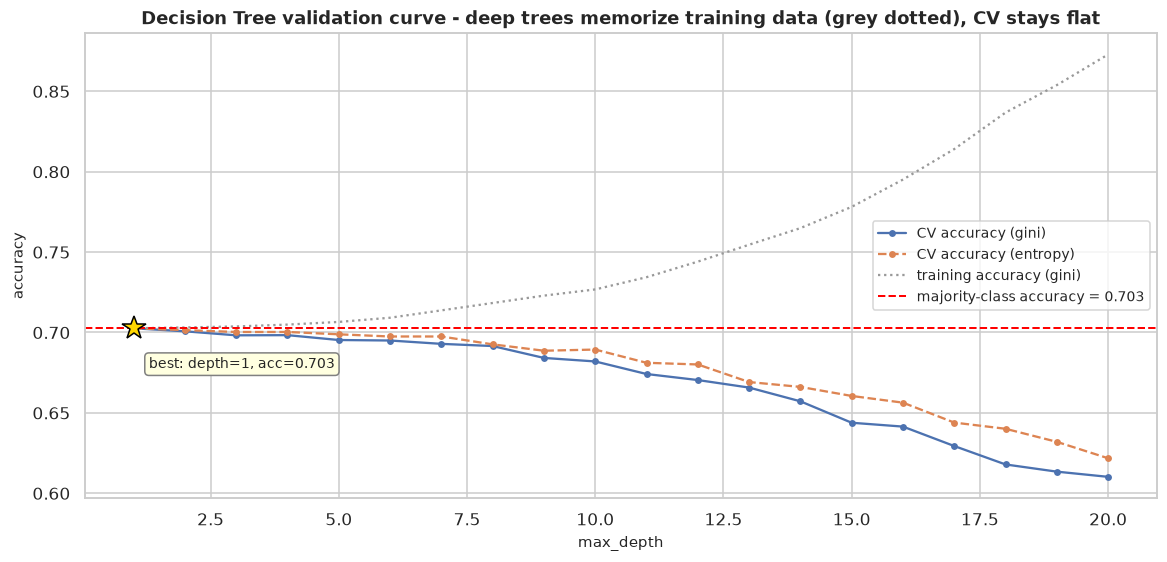

In [40]:
fig, ax = plt.subplots(figsize=(10.5, 5), constrained_layout=True)
for criterion, style in [("gini", "-"), ("entropy", "--")]:
    grp = dt_loop_df[dt_loop_df["criterion"] == criterion]
    ax.plot(grp["max_depth"], grp["cv_acc"], style, marker="o", markersize=3.5,
            color="#4C72B0" if criterion == "gini" else "#DD8452",
            label=f"CV accuracy ({criterion})")
ax.plot(dt_loop_df[dt_loop_df["criterion"] == "gini"]["max_depth"],
        dt_loop_df[dt_loop_df["criterion"] == "gini"]["train_acc"],
        ":", color="#999999", label="training accuracy (gini)")
ax.axhline(y_train.mean(), color="red", ls="--", lw=1.3,
           label=f"majority-class accuracy = {y_train.mean():.3f}")
ax.plot(best_dt_loop["max_depth"], best_dt_loop["cv_acc"], marker="*", markersize=16,
        color="gold", markeredgecolor="black", zorder=5)
ax.annotate(f"best: depth={best_dt_loop['max_depth']:.0f}, acc={best_dt_loop['cv_acc']:.3f}",
            (best_dt_loop["max_depth"], best_dt_loop["cv_acc"]), textcoords="offset points",
            xytext=(10, -26), fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Decision Tree validation curve - deep trees memorize training data (grey dotted), CV stays flat")
ax.legend(loc="center right", fontsize=9)
plt.show()

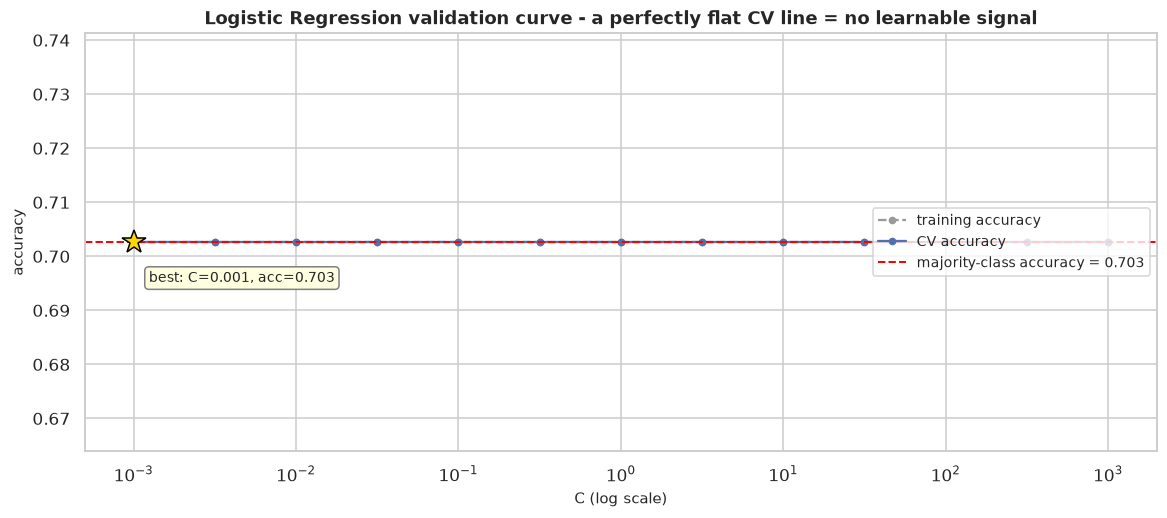

In [41]:
C_values = np.logspace(-3, 3, 13)
lr_loop_rows = []
for C in C_values:
    pipe = make_pipeline(LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE))
    pipe.fit(X_train, y_train)
    lr_loop_rows.append({
        "C": C,
        "train_acc": accuracy_score(y_train, pipe.predict(X_train)),
        "cv_acc": cross_val_score(pipe, X_train, y_train, cv=CV,
                                  scoring="accuracy", n_jobs=-1).mean(),
    })
lr_loop_df = pd.DataFrame(lr_loop_rows)
best_lr_loop = lr_loop_df.loc[lr_loop_df["cv_acc"].idxmax()]

fig, ax = plt.subplots(figsize=(10.5, 4.6), constrained_layout=True)
ax.semilogx(lr_loop_df["C"], lr_loop_df["train_acc"], "o--", color="#999999",
            markersize=4, label="training accuracy")
ax.semilogx(lr_loop_df["C"], lr_loop_df["cv_acc"], "o-", color="#4C72B0",
            markersize=4, label="CV accuracy")
ax.axhline(y_train.mean(), color="red", ls="--", lw=1.3,
           label=f"majority-class accuracy = {y_train.mean():.3f}")
ax.plot(best_lr_loop["C"], best_lr_loop["cv_acc"], marker="*", markersize=16,
        color="gold", markeredgecolor="black", zorder=5)
ax.annotate(f"best: C={best_lr_loop['C']:.3g}, acc={best_lr_loop['cv_acc']:.3f}",
            (best_lr_loop["C"], best_lr_loop["cv_acc"]), textcoords="offset points",
            xytext=(10, -26), fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))
ax.set_xlabel("C (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Logistic Regression validation curve - a perfectly flat CV line = no learnable signal")
ax.legend(loc="center right", fontsize=9)
plt.show()

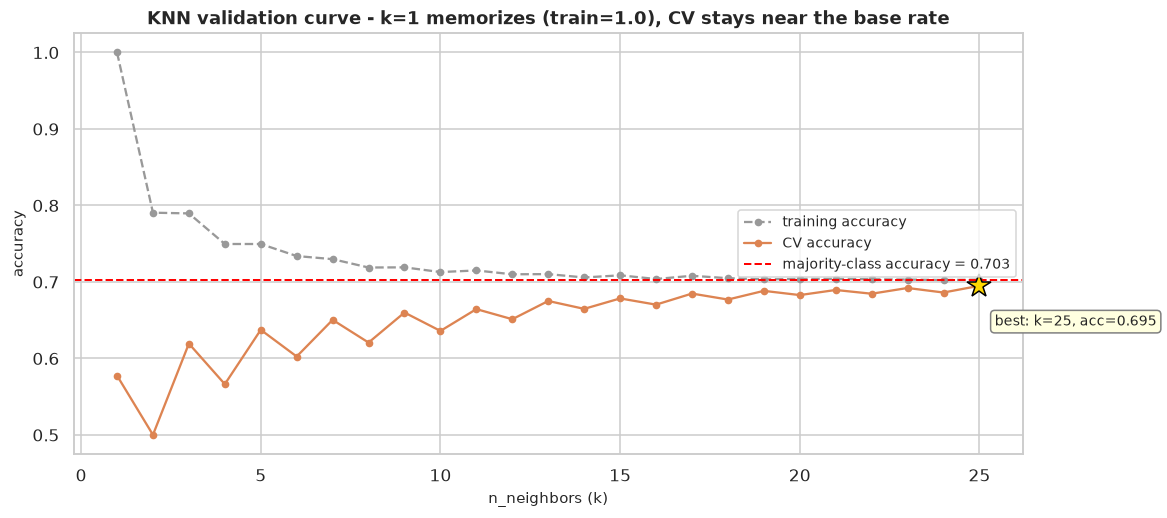

In [42]:
k_neighbors = range(1, 26)
knn_loop_rows = []
for k in k_neighbors:
    pipe = make_pipeline(KNeighborsClassifier(n_neighbors=k))
    pipe.fit(X_train, y_train)
    knn_loop_rows.append({
        "k": k,
        "train_acc": accuracy_score(y_train, pipe.predict(X_train)),
        "cv_acc": cross_val_score(pipe, X_train, y_train, cv=CV,
                                  scoring="accuracy", n_jobs=-1).mean(),
    })
knn_loop_df = pd.DataFrame(knn_loop_rows)
best_knn_loop = knn_loop_df.loc[knn_loop_df["cv_acc"].idxmax()]

fig, ax = plt.subplots(figsize=(10.5, 4.6), constrained_layout=True)
ax.plot(knn_loop_df["k"], knn_loop_df["train_acc"], "o--", color="#999999",
        markersize=4, label="training accuracy")
ax.plot(knn_loop_df["k"], knn_loop_df["cv_acc"], "o-", color="#DD8452",
        markersize=4, label="CV accuracy")
ax.axhline(y_train.mean(), color="red", ls="--", lw=1.3,
           label=f"majority-class accuracy = {y_train.mean():.3f}")
ax.plot(best_knn_loop["k"], best_knn_loop["cv_acc"], marker="*", markersize=16,
        color="gold", markeredgecolor="black", zorder=5)
ax.annotate(f"best: k={best_knn_loop['k']:.0f}, acc={best_knn_loop['cv_acc']:.3f}",
            (best_knn_loop["k"], best_knn_loop["cv_acc"]), textcoords="offset points",
            xytext=(10, -26), fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))
ax.set_xlabel("n_neighbors (k)")
ax.set_ylabel("accuracy")
ax.set_title("KNN validation curve - k=1 memorizes (train=1.0), CV stays near the base rate")
ax.legend(loc="center right", fontsize=9)
plt.show()

In [43]:
dt_param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 7, 9, 12, 15],
    "model__min_samples_leaf": [1, 5, 20, 50],
}
dt_grid = GridSearchCV(make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
                       dt_param_grid, cv=CV, scoring="roc_auc", n_jobs=-1)
dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for calla

In [ ]:
dt_cv = pd.DataFrame(dt_grid.cv_results_)
pivot_dt = dt_cv.pivot_table(index="param_model__max_depth",
                             columns="param_model__min_samples_leaf",
                             values="mean_test_score", aggfunc="mean").sort_index()

fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
im = ax.imshow(pivot_dt.values.astype(float), cmap="viridis", aspect="auto")
ax.set_xticks(range(pivot_dt.shape[1]), labels=pivot_dt.columns)
ax.set_yticks(range(pivot_dt.shape[0]), labels=pivot_dt.index.astype(int))
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")
ax.set_title("Decision Tree mean CV ROC-AUC (averaged over criterion)")
vmin, vmax = pivot_dt.values.min(), pivot_dt.values.max()
for i in range(pivot_dt.shape[0]):
    for j in range(pivot_dt.shape[1]):
        v = pivot_dt.values[i, j]
        frac = (v - vmin) / (vmax - vmin)
        ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=8,
                color="white" if frac < 0.55 else "black")
bi = list(pivot_dt.index).index(dt_grid.best_params_["model__max_depth"])
bj = list(pivot_dt.columns).index(dt_grid.best_params_["model__min_samples_leaf"])
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor="red", lw=2.5))
fig.colorbar(im, ax=ax, shrink=0.85, label="mean CV ROC-AUC")
plt.show()

top_dt = dt_cv.nlargest(5, "mean_test_score")[
    ["param_model__criterion", "param_model__max_depth",
     "param_model__min_samples_leaf", "mean_test_score", "std_test_score"]].reset_index(drop=True)
top_dt.columns = ["criterion", "max_depth", "min_samples_leaf", "mean CV ROC-AUC", "std"]
top_dt

Random Forest grid : 18 combinations x 5 folds
Best RF params     : {'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__n_estimators': 300}
Best RF CV ROC-AUC : 0.5097


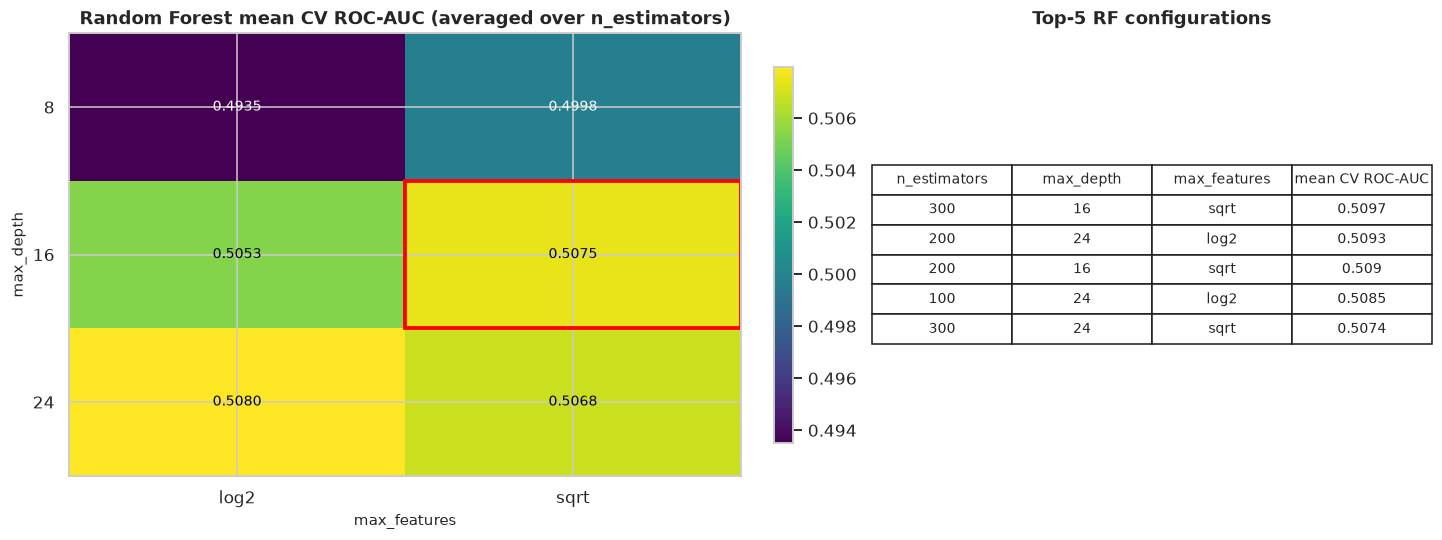

In [44]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 16, 24],
    "model__max_features": ["sqrt", "log2"],
}
rf_grid = GridSearchCV(
    make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
    rf_param_grid, cv=CV, scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"Random Forest grid : {np.prod([len(v) for v in rf_param_grid.values()])} combinations x 5 folds")
print(f"Best RF params     : {rf_grid.best_params_}")
print(f"Best RF CV ROC-AUC : {rf_grid.best_score_:.4f}")

rf_cv = pd.DataFrame(rf_grid.cv_results_)
pivot_rf = rf_cv.pivot_table(index="param_model__max_depth",
                             columns="param_model__max_features",
                             values="mean_test_score", aggfunc="mean").sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.2, 1]})
ax = axes[0]
im = ax.imshow(pivot_rf.values.astype(float), cmap="viridis", aspect="auto")
ax.set_xticks(range(pivot_rf.shape[1]), labels=pivot_rf.columns)
ax.set_yticks(range(pivot_rf.shape[0]), labels=pivot_rf.index.astype(int))
ax.set_xlabel("max_features")
ax.set_ylabel("max_depth")
ax.set_title("Random Forest mean CV ROC-AUC (averaged over n_estimators)")
vmin, vmax = pivot_rf.values.min(), pivot_rf.values.max()
for i in range(pivot_rf.shape[0]):
    for j in range(pivot_rf.shape[1]):
        v = pivot_rf.values[i, j]
        frac = (v - vmin) / (vmax - vmin)
        ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=9,
                color="white" if frac < 0.55 else "black")
bi = list(pivot_rf.index).index(rf_grid.best_params_["model__max_depth"])
bj = list(pivot_rf.columns).index(rf_grid.best_params_["model__max_features"])
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor="red", lw=2.5))
fig.colorbar(im, ax=ax, shrink=0.85)

ax = axes[1]
top_rf = rf_cv.nlargest(5, "mean_test_score")[
    ["param_model__n_estimators", "param_model__max_depth",
     "param_model__max_features", "mean_test_score"]].reset_index(drop=True)
top_rf.columns = ["n_estimators", "max_depth", "max_features", "mean CV ROC-AUC"]
ax.axis("off")
tbl = ax.table(cellText=top_rf.round(4).values.astype(str),
               colLabels=top_rf.columns, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
ax.set_title("Top-5 RF configurations")
plt.show()

Gradient Boosting grid : 8 combinations x 5 folds
Best GB params         : {'model__learning_rate': 0.15, 'model__max_depth': 3, 'model__n_estimators': 200}
Best GB CV ROC-AUC     : 0.5099


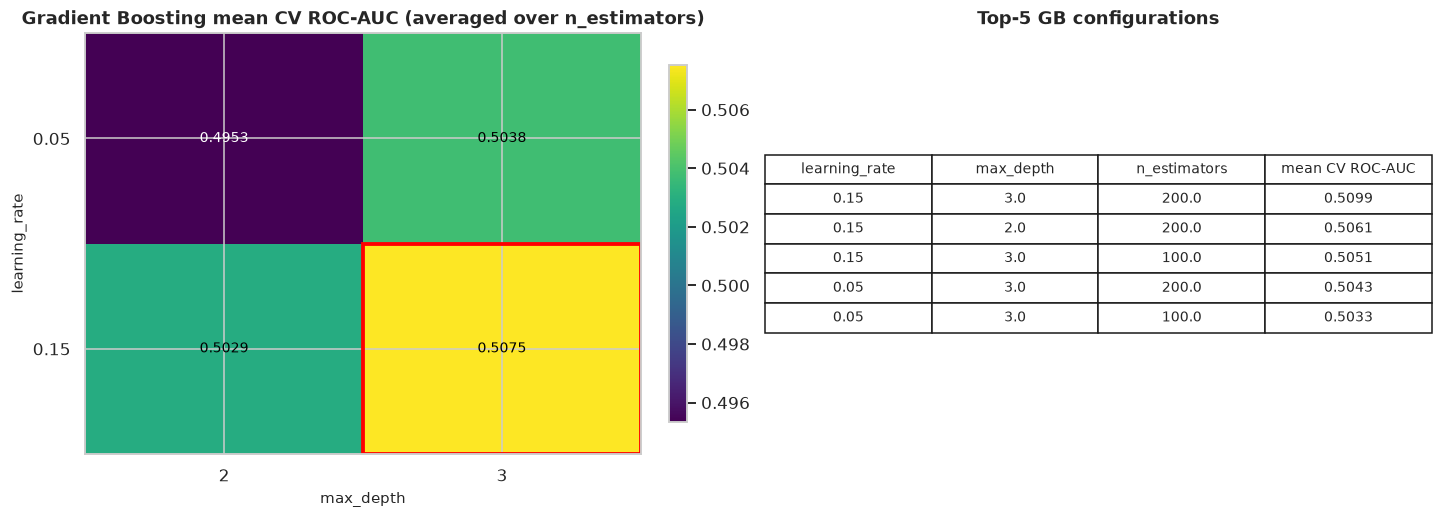

In [45]:
gb_param_grid = {
    "model__learning_rate": [0.05, 0.15],
    "model__max_depth": [2, 3],
    "model__n_estimators": [100, 200],
}
gb_grid = GridSearchCV(make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
                       gb_param_grid, cv=CV, scoring="roc_auc", n_jobs=-1)
gb_grid.fit(X_train, y_train)
print(f"Gradient Boosting grid : {np.prod([len(v) for v in gb_param_grid.values()])} combinations x 5 folds")
print(f"Best GB params         : {gb_grid.best_params_}")
print(f"Best GB CV ROC-AUC     : {gb_grid.best_score_:.4f}")

gb_cv = pd.DataFrame(gb_grid.cv_results_)
pivot_gb = gb_cv.pivot_table(index="param_model__learning_rate",
                             columns="param_model__max_depth",
                             values="mean_test_score", aggfunc="mean").sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1, 1.2]})
ax = axes[0]
im = ax.imshow(pivot_gb.values.astype(float), cmap="viridis", aspect="auto")
ax.set_xticks(range(pivot_gb.shape[1]), labels=pivot_gb.columns)
ax.set_yticks(range(pivot_gb.shape[0]), labels=[f"{c:.2f}" for c in pivot_gb.index])
ax.set_xlabel("max_depth")
ax.set_ylabel("learning_rate")
ax.set_title("Gradient Boosting mean CV ROC-AUC (averaged over n_estimators)")
vmin, vmax = pivot_gb.values.min(), pivot_gb.values.max()
for i in range(pivot_gb.shape[0]):
    for j in range(pivot_gb.shape[1]):
        v = pivot_gb.values[i, j]
        frac = (v - vmin) / (vmax - vmin)
        ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=9,
                color="white" if frac < 0.55 else "black")
bi = list(pivot_gb.index).index(gb_grid.best_params_["model__learning_rate"])
bj = list(pivot_gb.columns).index(gb_grid.best_params_["model__max_depth"])
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor="red", lw=2.5))
fig.colorbar(im, ax=ax, shrink=0.85)

ax = axes[1]
top_gb = gb_cv.nlargest(5, "mean_test_score")[
    ["param_model__learning_rate", "param_model__max_depth",
     "param_model__n_estimators", "mean_test_score"]].reset_index(drop=True)
top_gb.columns = ["learning_rate", "max_depth", "n_estimators", "mean CV ROC-AUC"]
ax.axis("off")
tbl = ax.table(cellText=top_gb.round(4).values.astype(str),
               colLabels=top_gb.columns, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
ax.set_title("Top-5 GB configurations")
plt.show()

In [46]:
best_lr_C = float(best_lr_loop["C"])
champions = {
    "Decision Tree (tuned)": dt_grid.best_estimator_,
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "Gradient Boosting (tuned)": gb_grid.best_estimator_,
    "Logistic Regression (tuned)": make_pipeline(
        LogisticRegression(C=best_lr_C, max_iter=1000, random_state=RANDOM_STATE)),
    "Dummy (majority)": make_pipeline(DummyClassifier(strategy="most_frequent")),
}

predictions, probabilities = {}, {}
for name, model in champions.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)
    print(f"fitted + predicted: {name}")

rows = []
for name in champions:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    report = classification_report(y_test, y_pred, output_dict=True)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced acc": balanced_accuracy_score(y_test, y_pred),
        "Precision (cred.)": report["1"]["precision"],
        "Recall (cred.)": report["1"]["recall"],
        "F1 (cred.)": report["1"]["f1-score"],
        "F1 (macro)": report["macro avg"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test, y_proba[:, 1]),
        "PR-AUC": average_precision_score(y_test, y_proba[:, 1]),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Kappa": cohen_kappa_score(y_test, y_pred),
        "Log loss": log_loss(y_test, y_proba, labels=[0, 1]),
        "Brier": brier_score_loss(y_test, y_proba[:, 1]),
    })

metrics_df = pd.DataFrame(rows).set_index("Model")
metrics_df.round(4)

fitted + predicted: Decision Tree (tuned)
fitted + predicted: Random Forest (tuned)
fitted + predicted: Gradient Boosting (tuned)
fitted + predicted: Logistic Regression (tuned)
fitted + predicted: Dummy (majority)


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

,Accuracy,Balanced acc,Precision (cred.),Recall (cred.),F1 (cred.),F1 (macro),ROC-AUC,PR-AUC,MCC,Kappa,Log loss,Brier
Model,,,,,,,,,,,,
Decision Tree (tuned),0.6929,0.5025,0.7036,0.9727,0.8165,0.4376,0.4852,0.6936,0.0135,0.0067,0.6305,0.2174
Random Forest (tuned),0.7025,0.5008,0.7028,0.9988,0.8251,0.4153,0.5001,0.6996,0.0181,0.0023,0.6145,0.2114
Gradient Boosting (tuned),0.6962,0.5000,0.7025,0.9846,0.8200,0.4246,0.4961,0.6977,-0.0001,-0.0000,0.6223,0.2143
Logistic Regression (tuned),0.7025,0.5000,0.7025,1.0000,0.8253,0.4126,0.5154,0.7132,0.0000,0.0000,0.6085,0.2089
Dummy (majority),0.7025,0.5000,0.7025,1.0000,0.8253,0.4126,0.5000,0.7025,0.0000,0.0000,10.7230,0.2975


In [47]:
top2 = (metrics_df.drop(index="Dummy (majority)")["ROC-AUC"]
        .nlargest(2).index.tolist())

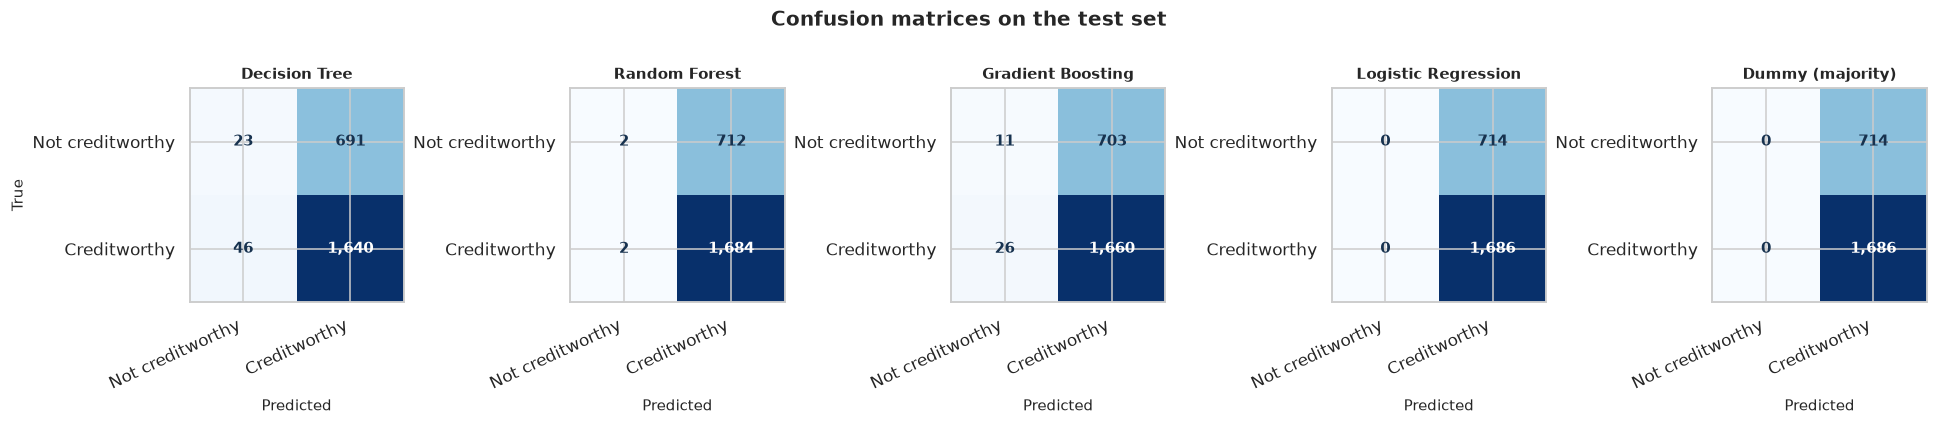

In [48]:
fig, axes = plt.subplots(1, 5, figsize=(17.5, 3.8), constrained_layout=True)
class_names = ["Not creditworthy", "Creditworthy"]
for ax, name in zip(axes, champions):
    cm = confusion_matrix(y_test, predictions[name])
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_xticks([0, 1], labels=class_names, rotation=25, ha="right")
    ax.set_yticks([0, 1], labels=class_names)
    ax.set_xlabel("Predicted")
    if ax is axes[0]:
        ax.set_ylabel("True")
    short = name.replace(" (tuned)", "")
    ax.set_title(f"{short}", fontsize=10)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=10,
                    fontweight="bold",
                    color="white" if cm[i, j] > thresh else "#17324f")
fig.suptitle("Confusion matrices on the test set", fontsize=13, fontweight="bold")
plt.show()

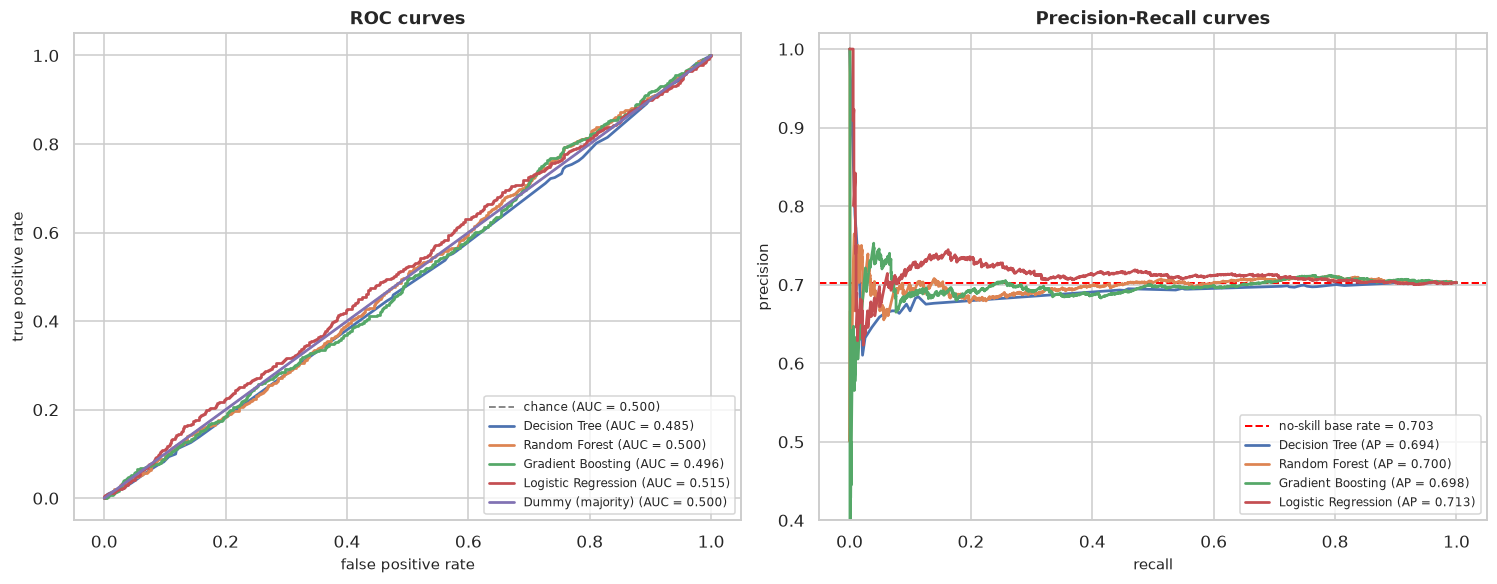

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=True)

ax = axes[0]
ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=1.2, label="chance (AUC = 0.500)")
for name in champions:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name][:, 1])
    ax.plot(fpr, tpr, lw=1.8, label=f"{name.replace(' (tuned)', '')} (AUC = {auc(fpr, tpr):.3f})")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves")
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
ax.axhline(y_test.mean(), color="red", ls="--", lw=1.3,
           label=f"no-skill base rate = {y_test.mean():.3f}")
for name in champions:
    if name == "Dummy (majority)":
        continue
    prec, rec, _ = precision_recall_curve(y_test, probabilities[name][:, 1])
    ax.plot(rec, prec, lw=1.8,
            label=f"{name.replace(' (tuned)', '')} (AP = {average_precision_score(y_test, probabilities[name][:, 1]):.3f})")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision-Recall curves")
ax.set_ylim(0.4, 1.02)
ax.legend(loc="lower right", fontsize=8)
plt.show()

In [53]:
from sklearn.inspection import permutation_importance

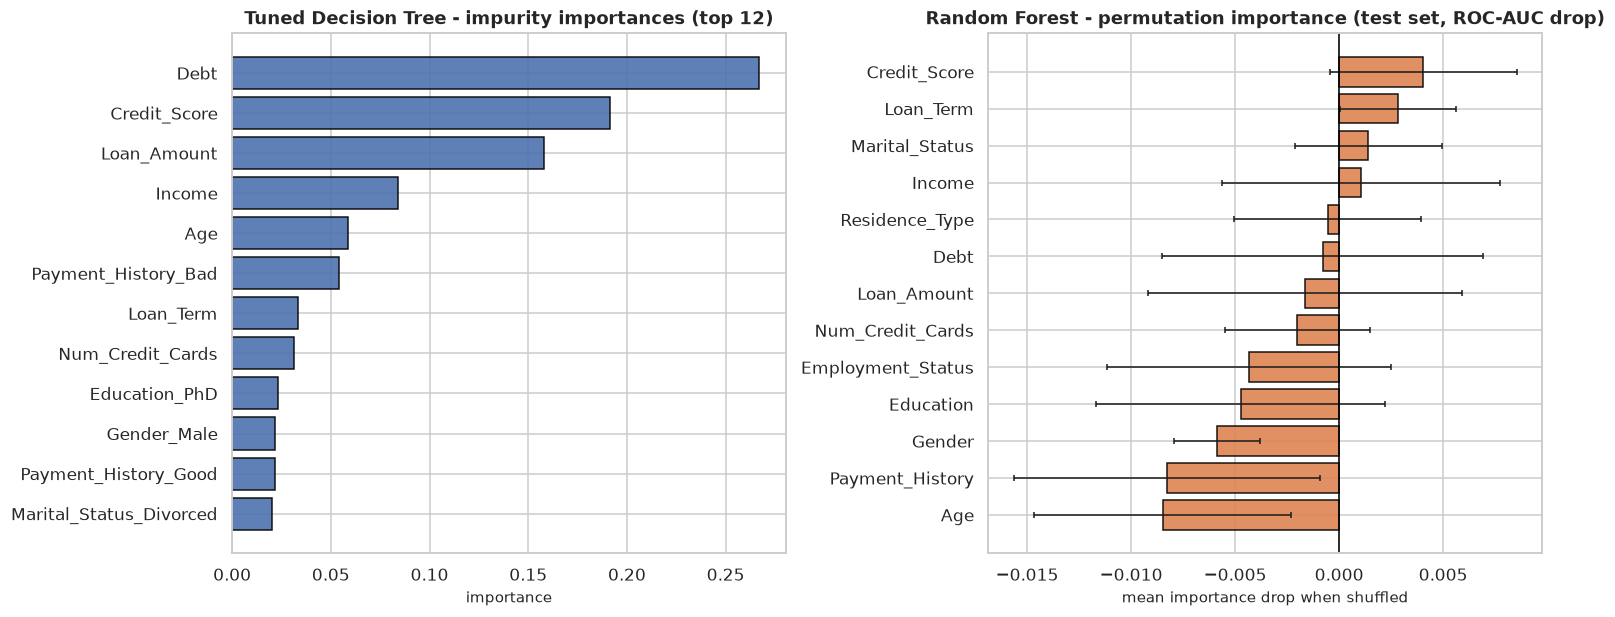

In [53]:
dt_model = champions["Decision Tree (tuned)"].named_steps["model"]

dt_imp = pd.Series(dt_model.feature_importances_, index=feature_names).sort_values(ascending=False)

perm = permutation_importance(champions["Random Forest (tuned)"], X_test, y_test,
                              scoring="roc_auc", n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns)
perm_std = pd.Series(perm.importances_std, index=X_test.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
axes[0].barh(dt_imp.head(12).index[::-1], dt_imp.head(12).values[::-1],
             color="#4C72B0", edgecolor="black", alpha=0.9)
axes[0].set_title("Tuned Decision Tree - impurity importances (top 12)")
axes[0].set_xlabel("importance")

order = perm_imp.sort_values().index
axes[1].barh(order, perm_imp[order], xerr=perm_std[order],
             color="#DD8452", edgecolor="black", alpha=0.9,
             error_kw={"lw": 1, "capsize": 2})
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Random Forest - permutation importance (test set, ROC-AUC drop)")
axes[1].set_xlabel("mean importance drop when shuffled")
plt.show()


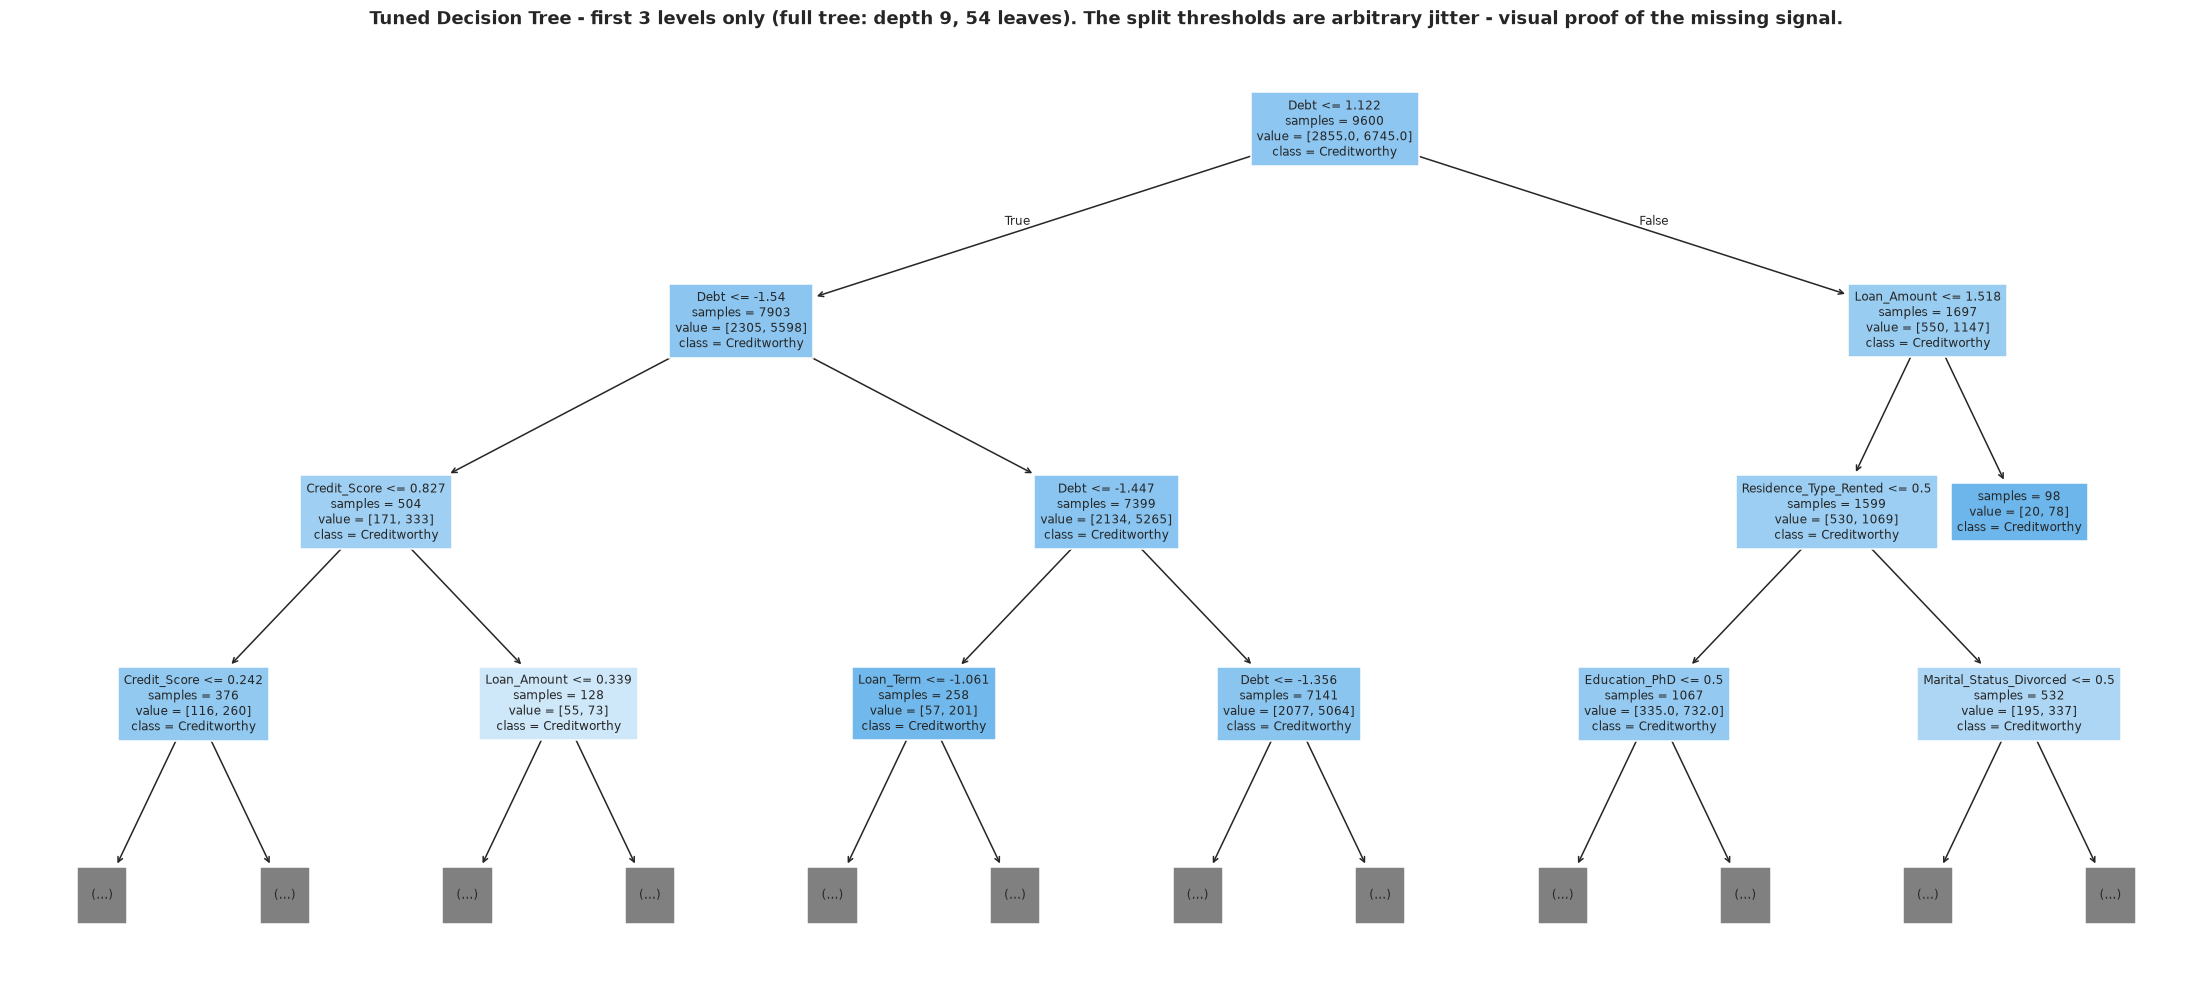

In [ ]:
fig, ax = plt.subplots(figsize=(20, 9), constrained_layout=True)
plot_tree(dt_model, feature_names=feature_names,
          class_names=["Not creditworthy", "Creditworthy"],
          filled=True, max_depth=3, fontsize=8, impurity=False, ax=ax)
ax.set_title(f"Tuned Decision Tree - first 3 levels only "
             f"(full tree: depth {dt_model.get_depth()}, {dt_model.get_n_leaves()} leaves). "
             "The split thresholds are  arbitrary jitter - visual proof of the missing signal.")
plt.show()